Fitting 3 folds for each of 108 candidates, totalling 324 fits


C:\Users\arsal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
162 fits failed out of a total of 324.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
71 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\arsal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\arsal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-pa


Best Random Forest parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}

--- TRAIN METRICS ---
RMSE  : 398.0912
MAE   : 232.3434
Median AE : 118.6046
R²    : 0.9681
Explained Variance : 0.9681
Max Error : 3558.4566
MAPE (%)  : 5.47
sMAPE (%) : 5.10
MSLE      : 0.009960278396393983


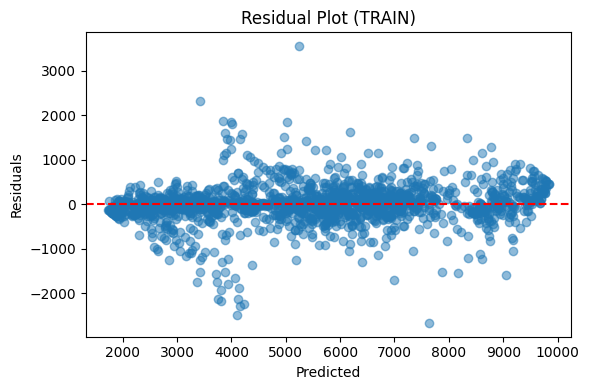


--- VALIDATION METRICS ---
RMSE  : 409.2881
MAE   : 296.3358
Median AE : 222.3877
R²    : 0.9125
Explained Variance : 0.9126
Max Error : 2801.6402
MAPE (%)  : 7.62
sMAPE (%) : 7.36
MSLE      : 0.01156605137487822


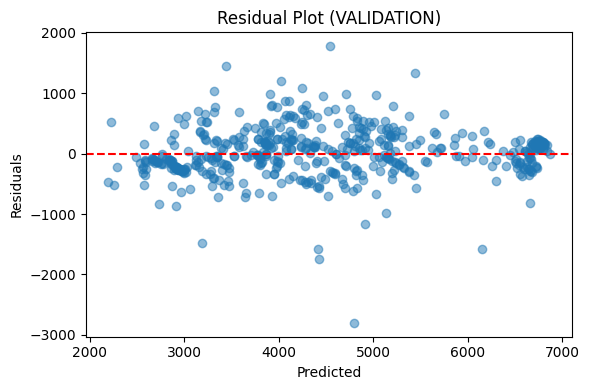


--- TEST METRICS ---
RMSE  : 646.1287
MAE   : 455.0722
Median AE : 346.7368
R²    : 0.9412
Explained Variance : 0.9427
Max Error : 3320.6567
MAPE (%)  : 10.14
sMAPE (%) : 9.82
MSLE      : 0.016578598170442653


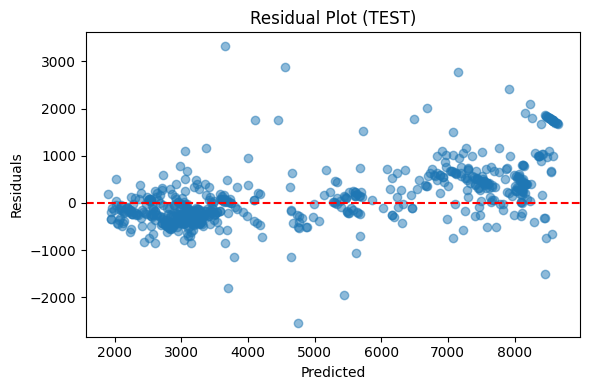

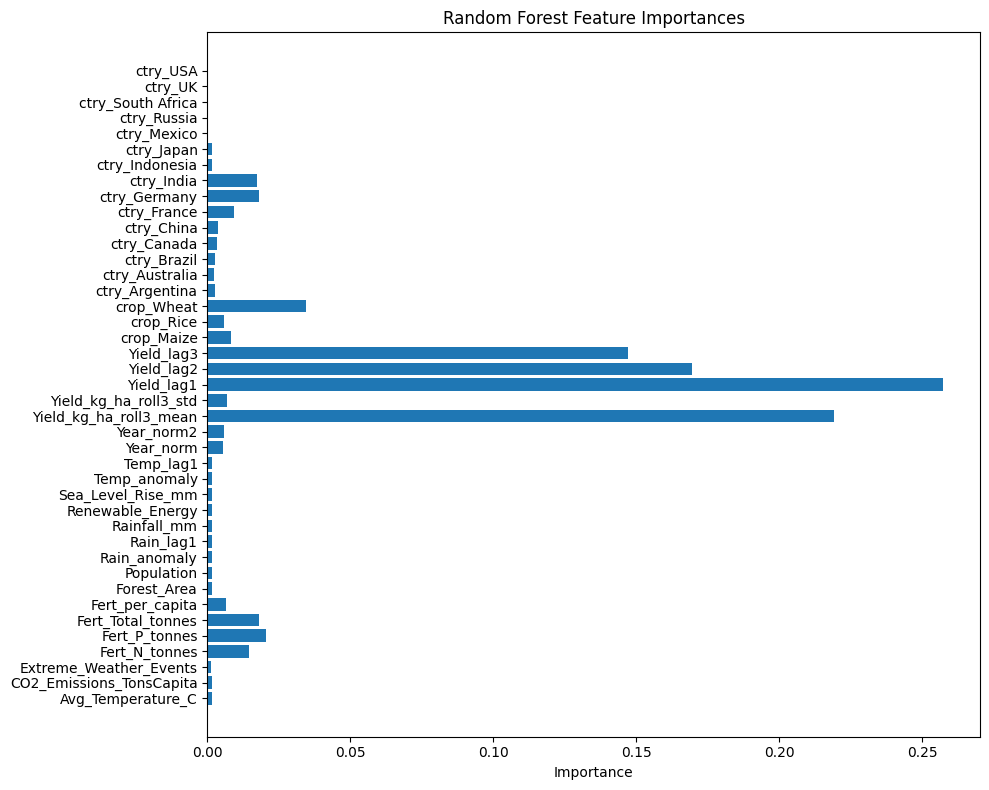


Pipeline saved as 'models/rf_pipeline.pkl'


In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, r2_score, explained_variance_score, 
    median_absolute_error, max_error, mean_squared_log_error
)

# ================================
# STEP 0: LOAD DATA
# ================================
df = pd.read_csv("data/cleaned/final_cleaned_dataset.csv")

# ================================
# STEP 1: TARGET & FEATURES
# ================================
target_candidates = [col for col in df.columns if "yield" in col.lower()]
if not target_candidates:
    raise ValueError("No column with 'yield' found in dataset!")
target = target_candidates[0]

exclude_cols = ["Country", "Year"]
features = list(df.columns.difference(exclude_cols + [target]))
X = df[features]
y = df[target]

# ================================
# STEP 2: SPLIT DATA
# ================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, shuffle=False
)

# ================================
# STEP 3: SCALE FEATURES
# ================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/scaler_rf.pkl")

# ================================
# STEP 4: RANDOM FOREST + GRID SEARCH
# ================================
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt"]
}

grid_search = GridSearchCV(
    rf, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=2
)
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
print("\nBest Random Forest parameters:", grid_search.best_params_)

# ================================
# STEP 5: PREDICTIONS
# ================================
y_pred_train = best_rf.predict(X_train_scaled)
y_pred_val   = best_rf.predict(X_val_scaled)
y_pred_test  = best_rf.predict(X_test_scaled)

# ================================
# STEP 6: METRICS FUNCTION
# ================================
def regression_metrics(y_true, y_pred, name="Dataset"):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae  = mean_absolute_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    ev   = explained_variance_score(y_true, y_pred)
    maxerr = max_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))
    msle = mean_squared_log_error(y_true, y_pred) if (y_true >= 0).all() and (y_pred >= 0).all() else np.nan

    print(f"\n--- {name} METRICS ---")
    print(f"RMSE  : {rmse:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"Median AE : {medae:.4f}")
    print(f"R²    : {r2:.4f}")
    print(f"Explained Variance : {ev:.4f}")
    print(f"Max Error : {maxerr:.4f}")
    print(f"MAPE (%)  : {mape:.2f}")
    print(f"sMAPE (%) : {smape:.2f}")
    print(f"MSLE      : {msle}")

    # Residual plot
    residuals = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot ({name})")
    plt.tight_layout()
    plt.show()

# ================================
# STEP 7: EVALUATE TRAIN, VAL, TEST
# ================================
regression_metrics(y_train, y_pred_train, "TRAIN")
regression_metrics(y_val, y_pred_val, "VALIDATION")
regression_metrics(y_test, y_pred_test, "TEST")

# ================================
# STEP 8: FEATURE IMPORTANCE
# ================================
feat_importances = best_rf.feature_importances_

plt.figure(figsize=(10,8))
plt.barh(features, feat_importances)
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# ================================
# STEP 9: PER-CROP PERFORMANCE
# ================================
if "Crop" in df.columns:
    crops = df.loc[X_test.index, "Crop"].unique()
    print("\n=== PER-CROP PERFORMANCE ===")
    for crop in crops:
        idx = df.loc[X_test.index, "Crop"] == crop
        y_true_crop = y_test[idx]
        y_pred_crop = y_pred_test[idx]
        if len(y_true_crop) > 0:
            rmse_crop = np.sqrt(np.mean((y_true_crop - y_pred_crop) ** 2))
            r2_crop = r2_score(y_true_crop, y_pred_crop)
            print(f"{crop:10}: R² = {r2_crop:.4f}, RMSE = {rmse_crop:.2f}, n = {len(y_true_crop)}")

# ================================
# STEP 10: SAVE PIPELINE
# ================================
pipeline = Pipeline([
    ("scaler", scaler),
    ("rf", best_rf)
])
joblib.dump(pipeline, "models/rf_pipeline.pkl")
print("\nPipeline saved as 'models/rf_pipeline.pkl'")